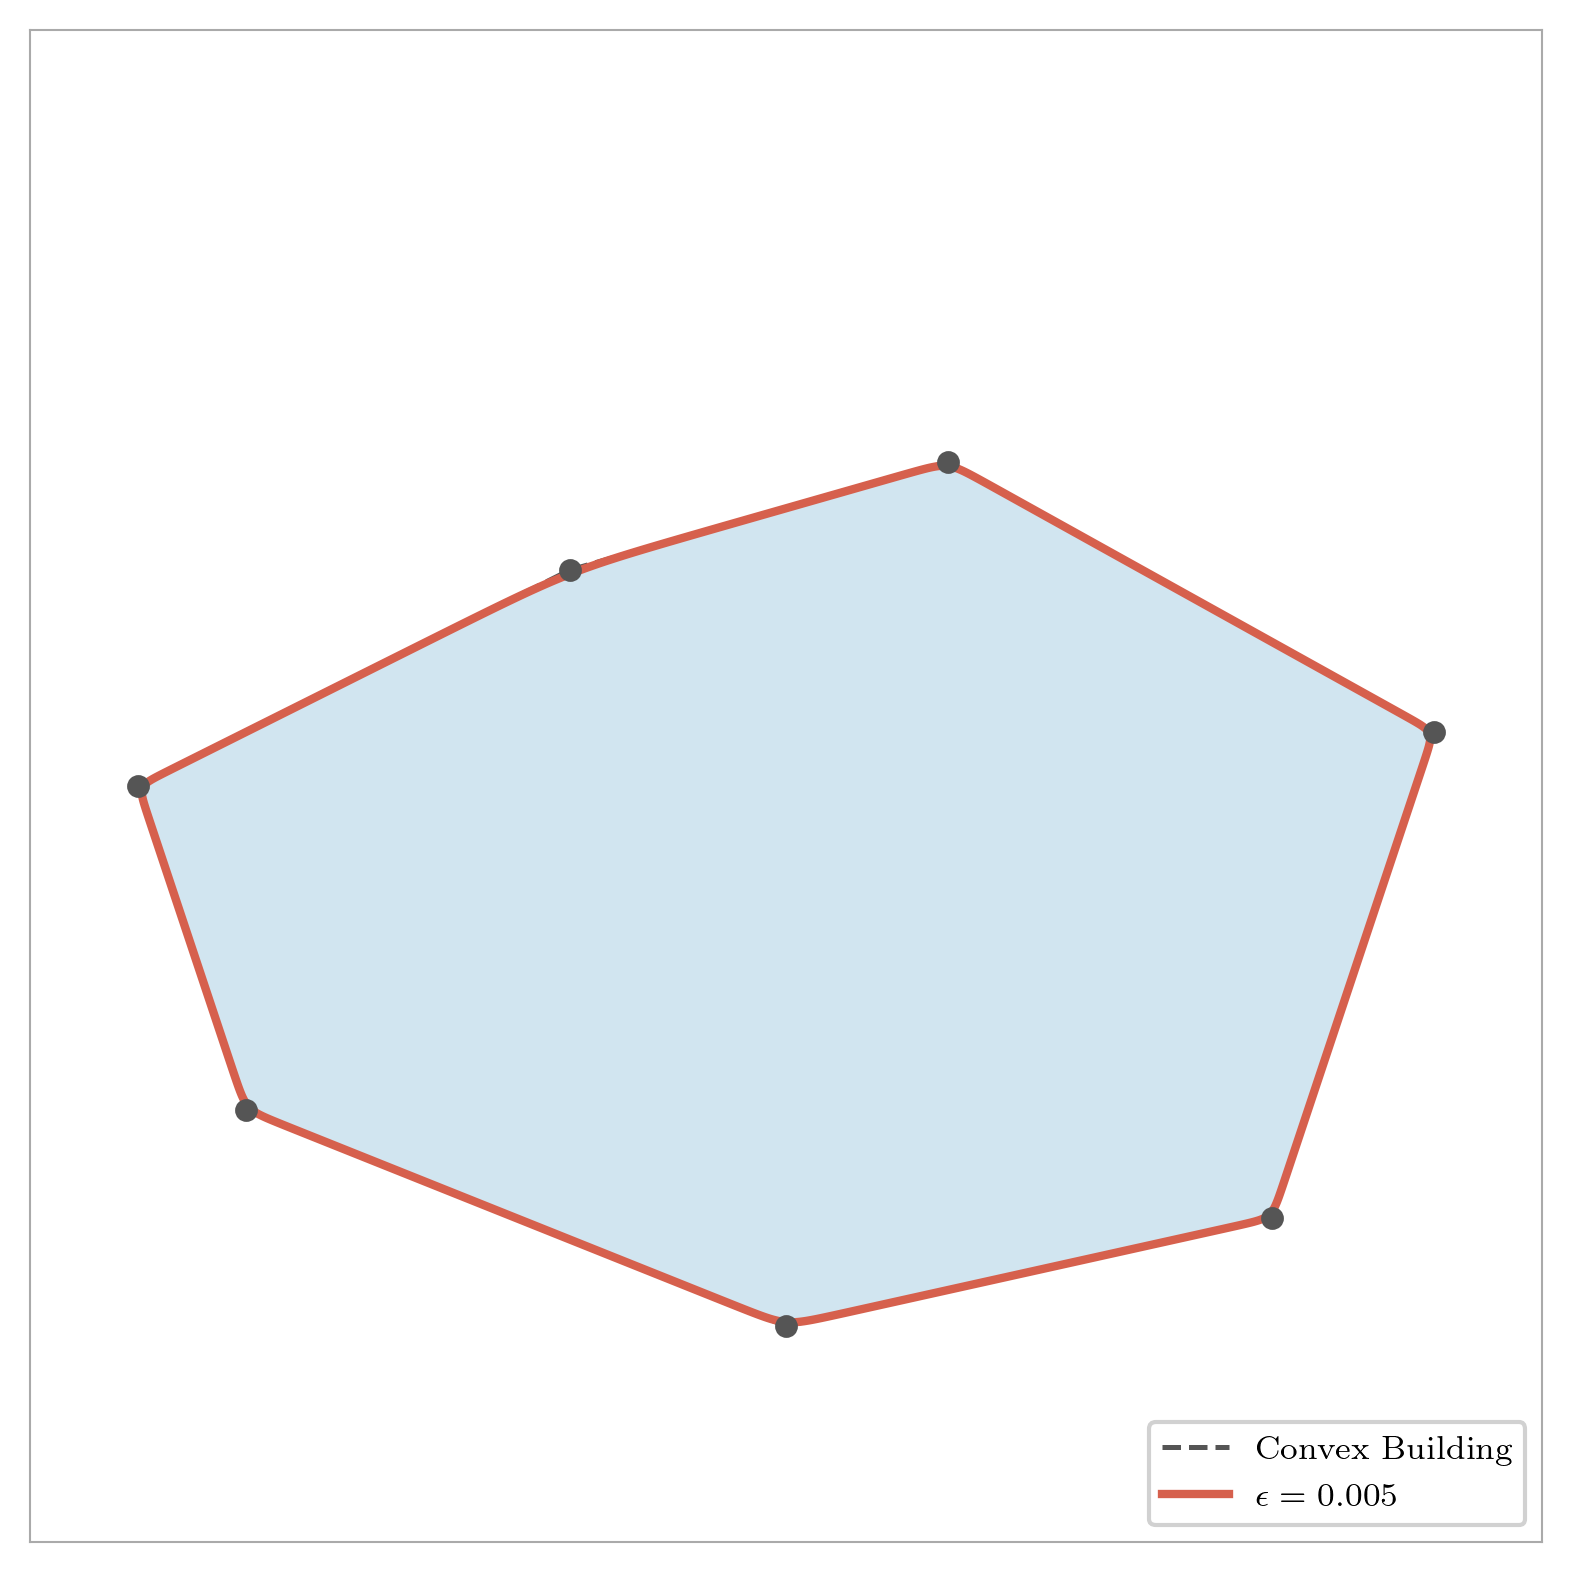

In [1]:
import numpy as np
import matplotlib
matplotlib.rcParams['text.usetex'] = True  # set False if LaTeX not available
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.size'] = 10
matplotlib.rcParams['axes.linewidth'] = 0.5
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.lines import Line2D
import matplotlib as mpl
mpl.rcParams['font.size'] = 14
mpl.rcParams['text.usetex'] = True

# ── USER SETTINGS ────────────────────────────────────────────────────────────
EPSILON = 0.005        # change this: try 0.5, 0.1, 0.02
SENSOR_EDGE = 1      # which edge (0-indexed) to place the sensor on (0 to 4)
OUTPUT_FILE = f'lse_boundary_eps{EPSILON}.pdf'
# ─────────────────────────────────────────────────────────────────────────────

# Convex pentagon building
# vertices = np.array([
#     [0.5,  1.0],   # top
#     [1.0,  0.65],  # right-top
#     [0.85, 0.0],   # right-bottom
#     [0.15, 0.0],   # left-bottom
#     [0.0,  0.65],  # left-top
# ])
vertices = np.array([
    [0.3,  0.7],   # top-left
    [0.65, 0.8],   # top-right
    [1.1,  0.55],  # right
    [0.95, 0.1],   # bottom-right
    [0.5,  0.0],   # bottom-middle
    [0.0,  0.2],   # bottom-left
    [-0.1, 0.5],   # left
])
verts_closed = np.vstack([vertices, vertices[0]])

# Half-space representation: A x <= b (outward normals)
def compute_halfspaces(verts):
    n = len(verts)
    A, b = [], []
    for i in range(n):
        p1, p2 = verts[i], verts[(i + 1) % n]
        edge = p2 - p1
        normal = np.array([-edge[1], edge[0]])  # fix: flip sign
        normal /= np.linalg.norm(normal)
        A.append(normal)
        b.append(normal @ p1)
    return np.array(A), np.array(b)

A_mat, b_vec = compute_halfspaces(vertices)

# Log-sum-exp boundary residual R(x)
def lse_boundary(x, y, A, b, eps):
    pt = np.array([x, y])
    vals = (A @ pt - b) / eps
    vmax = np.max(vals)
    return eps * (np.log(np.sum(np.exp(vals - vmax))) + vmax)

# Grid for contour
xx, yy = np.meshgrid(np.linspace(-0.2, 1.2, 800),
                     np.linspace(-0.2, 1.2, 800))
R = np.vectorize(lambda x, y: lse_boundary(x, y, A_mat, b_vec, EPSILON))(xx, yy)

# Sensor position: midpoint of selected edge
p1 = vertices[SENSOR_EDGE]
p2 = vertices[(SENSOR_EDGE + 1) % len(vertices)]
sensor_pos = 0.5 * (p1 + p2)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
fig.subplots_adjust(left=0.05, right=0.95, top=0.92, bottom=0.08)

# Building fill
poly_patch = Polygon(vertices, closed=True,
                     facecolor='#d1e5f0', edgecolor='none', zorder=1)
ax.add_patch(poly_patch)

# Hard boundary (exact polygon)
ax.plot(verts_closed[:, 0], verts_closed[:, 1],
        color='#555555', linewidth=1.2, linestyle='--',
        zorder=3, label=r'Hard constraint')

# Zero level set (smooth boundary)
cs = ax.contour(xx, yy, R, levels=[0.0],
                colors=['#d6604d'], linewidths=2.0, zorder=4)

# Sensor dot
# ax.scatter(*sensor_pos, s=60, color='#e6700b',
#            zorder=6, clip_on=False, label=r'Sensor $\mathbf{x}_j$')

# Vertex dots on hard boundary
for v in vertices:
    ax.scatter(*v, s=20, color='#555555', zorder=5, clip_on=False)

ax.set_xlim(-0.2, 1.2)
ax.set_ylim(-0.2, 1.2)
ax.set_aspect('equal')
# ax.set_title(r'$\epsilon = ' + str(EPSILON) + r'$', fontsize=10, pad=6)
ax.tick_params(left=False, bottom=False,
               labelleft=False, labelbottom=False)
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_color('#aaaaaa')

# Legend
lse_line = Line2D([0], [0], color='#d6604d', linewidth=2.0,
                  label=r'$\epsilon = ' + str(EPSILON) + r'$')
hard_line = Line2D([0], [0], color='#555555', linewidth=1.2,
                   linestyle='--', label=r'Convex Building')
# sensor_dot = Line2D([0], [0], marker='o', color='w',
#                     markerfacecolor='#e6700b', markersize=6,
#                     label=r'Sensor $\mathbf{x}_j$')
ax.legend(handles=[hard_line, lse_line],
          fontsize=8, loc='lower right',
          framealpha=0.9, edgecolor='#cccccc')
# plt.savefig("concept_diagram_sec_III_A_epsilon_"+str(EPSILON)+".png", bbox_inches="tight", dpi=300)

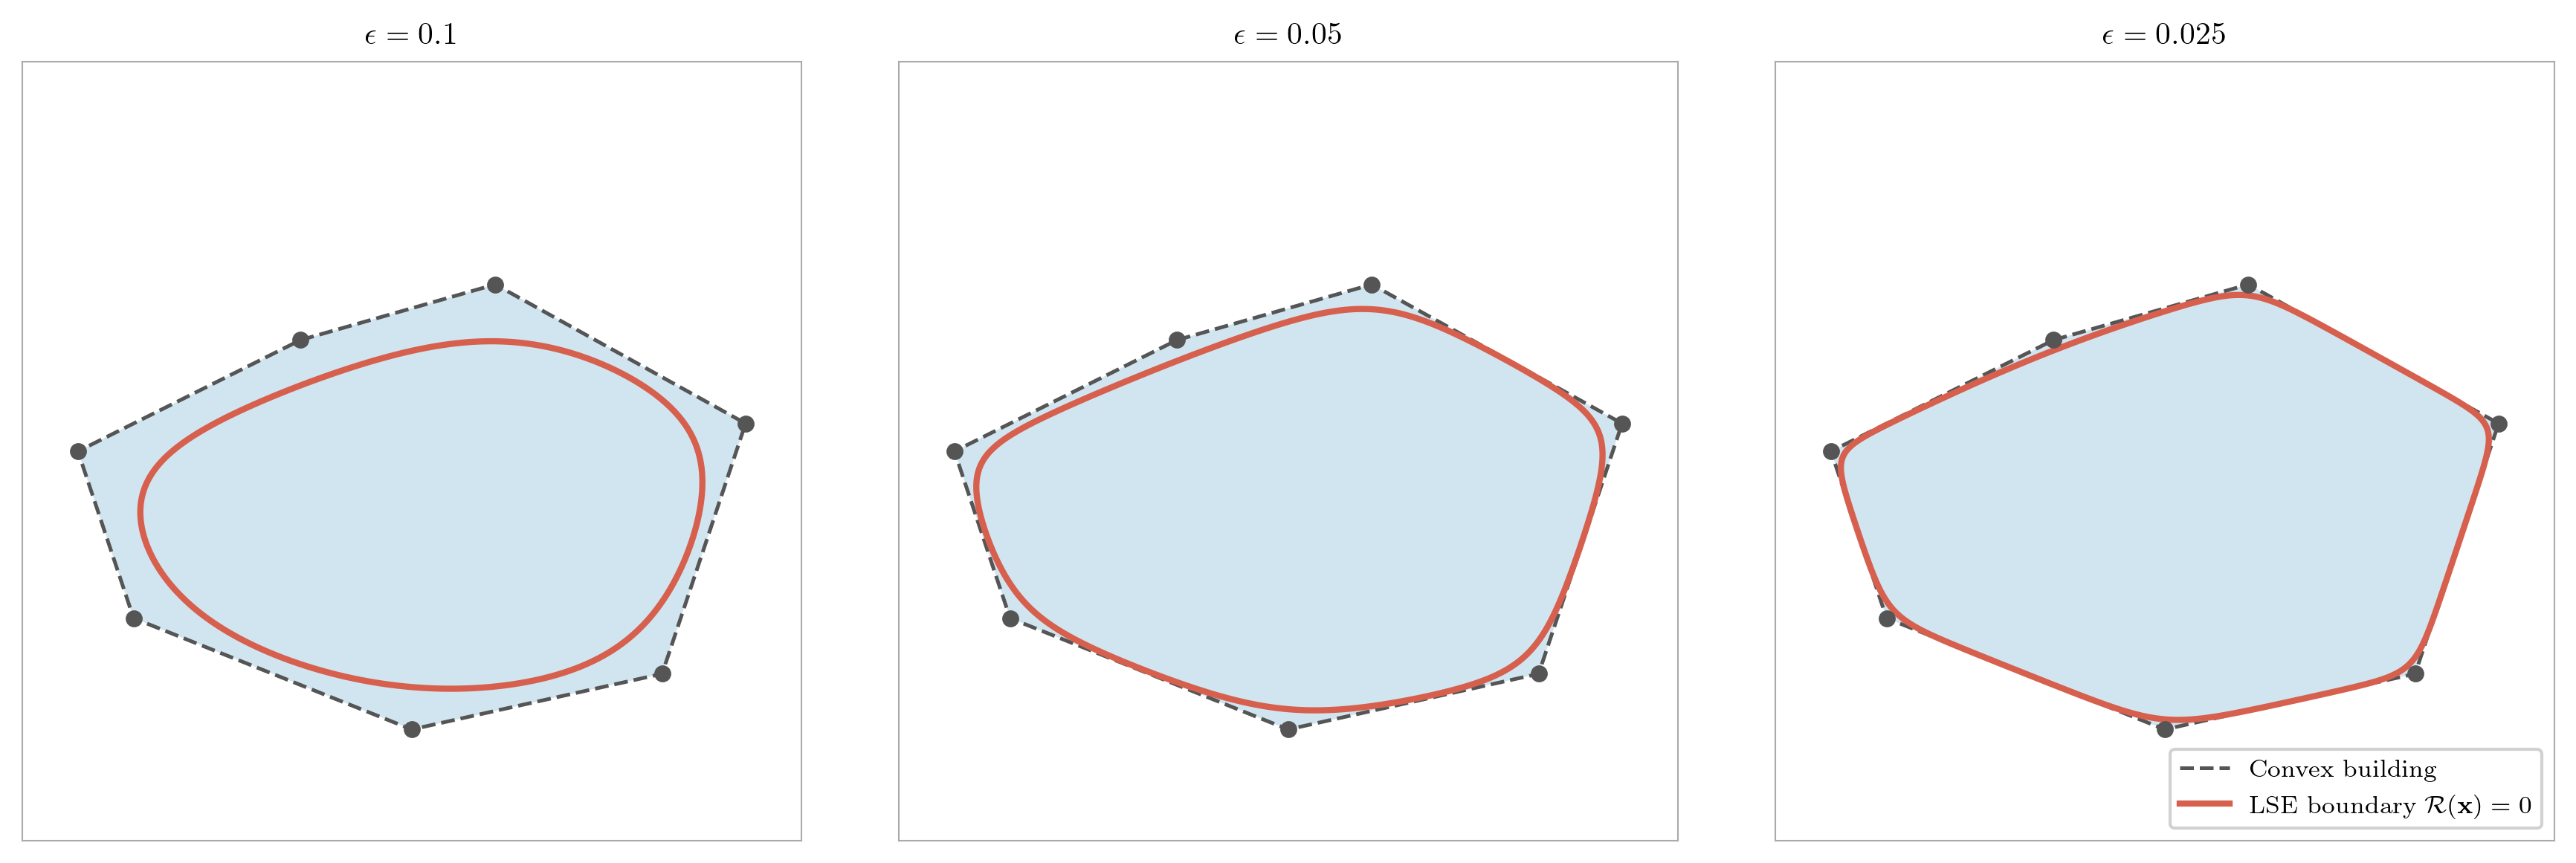

In [2]:
epsilons = [0.1, 0.05, 0.025]

fig, axes = plt.subplots(1, 3, figsize=(12, 4), dpi=300)
fig.subplots_adjust(left=0.05, right=0.95, top=0.92, bottom=0.08)

for ax, eps in zip(axes, epsilons):
    R = np.vectorize(lambda x, y: lse_boundary(x, y, A_mat, b_vec, eps))(xx, yy)

    # Building fill
    poly_patch = Polygon(vertices, closed=True,
                         facecolor='#d1e5f0', edgecolor='none', zorder=1)
    ax.add_patch(poly_patch)

    # Hard boundary (exact polygon)
    ax.plot(verts_closed[:, 0], verts_closed[:, 1],
            color='#555555', linewidth=1.2, linestyle='--', zorder=3)

    # Zero level set (smooth boundary)
    ax.contour(xx, yy, R, levels=[0.0],
               colors=['#d6604d'], linewidths=2.0, zorder=4)

    # Vertex dots on hard boundary
    for v in vertices:
        ax.scatter(*v, s=20, color='#555555', zorder=5, clip_on=False)

    ax.set_xlim(-0.2, 1.2)
    ax.set_ylim(-0.2, 1.2)
    ax.set_aspect('equal')
    ax.set_title(r'$\epsilon = ' + str(eps) + r'$', fontsize=10, pad=6)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
        spine.set_color('#aaaaaa')

# Single legend on the last (rightmost) axes
lse_line  = Line2D([0], [0], color='#d6604d', linewidth=2.0,
                   label=r'LSE boundary $\mathcal{R}(\mathbf{x})=0$')
hard_line = Line2D([0], [0], color='#555555', linewidth=1.2,
                   linestyle='--', label=r'Convex building')
axes[-1].legend(handles=[hard_line, lse_line],
                fontsize=8, loc='lower right',
                framealpha=0.9, edgecolor='#cccccc')

plt.tight_layout()
# plt.savefig("concept_diagram_sec_III_A_epsilon_comparison.png", bbox_inches="tight", dpi=300)

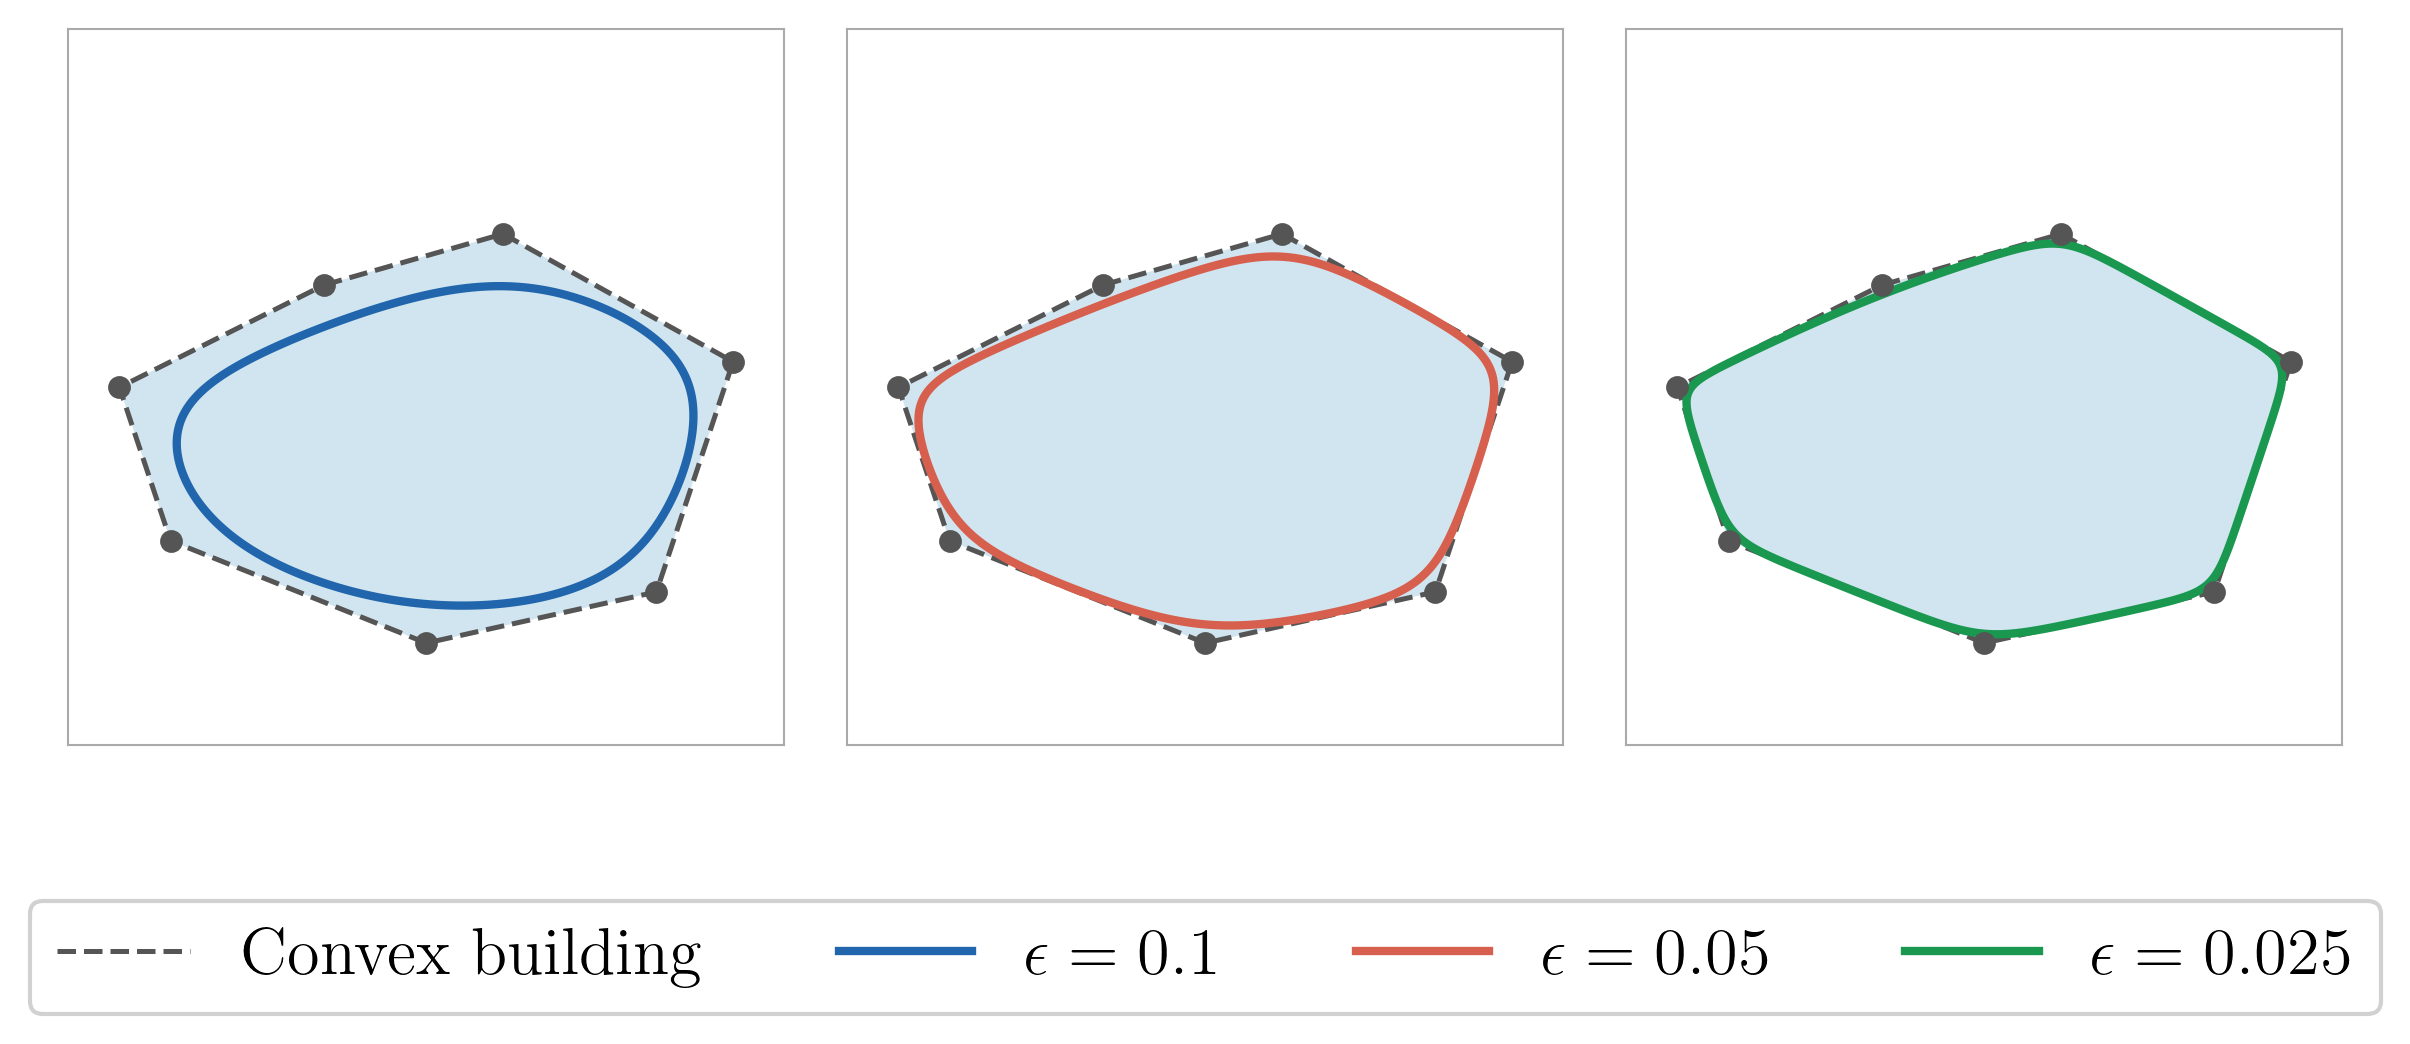

In [17]:
mpl.rcParams['font.size'] = 14
mpl.rcParams['text.usetex'] = True

epsilons = [0.1, 0.05, 0.025]
colors    = ['#2166ac', '#d6604d', '#1a9850']  # blue, red, green

fig, axes = plt.subplots(1, 3, figsize=(8, 4), dpi=300)
fig.subplots_adjust(left=0.05, right=0.95, top=0.92, bottom=0.08)

for ax, eps, color in zip(axes, epsilons, colors):
    R = np.vectorize(lambda x, y: lse_boundary(x, y, A_mat, b_vec, eps))(xx, yy)

    # Building fill
    poly_patch = Polygon(vertices, closed=True,
                         facecolor='#d1e5f0', edgecolor='none', zorder=1)
    ax.add_patch(poly_patch)

    # Hard boundary (exact polygon)
    ax.plot(verts_closed[:, 0], verts_closed[:, 1],
            color='#555555', linewidth=1.2, linestyle='--', zorder=3)

    # Zero level set (smooth boundary)
    ax.contour(xx, yy, R, levels=[0.0],
               colors=[color], linewidths=2.0, zorder=4)

    # Vertex dots on hard boundary
    for v in vertices:
        ax.scatter(*v, s=20, color='#555555', zorder=5, clip_on=False)

    ax.set_xlim(-0.2, 1.2)
    ax.set_ylim(-0.2, 1.2)
    ax.set_aspect('equal')
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
        spine.set_color('#aaaaaa')

# # Single legend on the last (rightmost) axes
# hard_line = Line2D([0], [0], color='#555555', linewidth=1.2,
#                    linestyle='--', label=r'Convex building')
# legend_handles = [hard_line] + [
#     Line2D([0], [0], color=color, linewidth=2.0,
#            label=r'$\epsilon = ' + str(eps) + r'$')
#     for eps, color in zip(epsilons, colors)
# ]
# axes[-1].legend(handles=legend_handles,
#                 fontsize=14, loc='lower right',
#                 framealpha=0.9, edgecolor='#cccccc')

# plt.tight_layout()
# plt.savefig("concept_diagram_sec_III_A_epsilon_comparison.pdf", bbox_inches="tight", dpi=300)

hard_line = Line2D([0], [0], color='#555555', linewidth=1.2,
                   linestyle='--', label=r'Convex building')
legend_handles = [hard_line] + [
    Line2D([0], [0], color=color, linewidth=2.0,
           label=r'$\epsilon = ' + str(eps) + r'$')
    for eps, color in zip(epsilons, colors)
]
fig.legend(handles=legend_handles,
           fontsize=16, loc='lower center',
           ncol=4,  # all 4 items in one row
           framealpha=0.9, edgecolor='#cccccc',
           bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.savefig("concept_diagram_sec_III_A_epsilon_comparison.pdf", bbox_inches="tight", dpi=300)

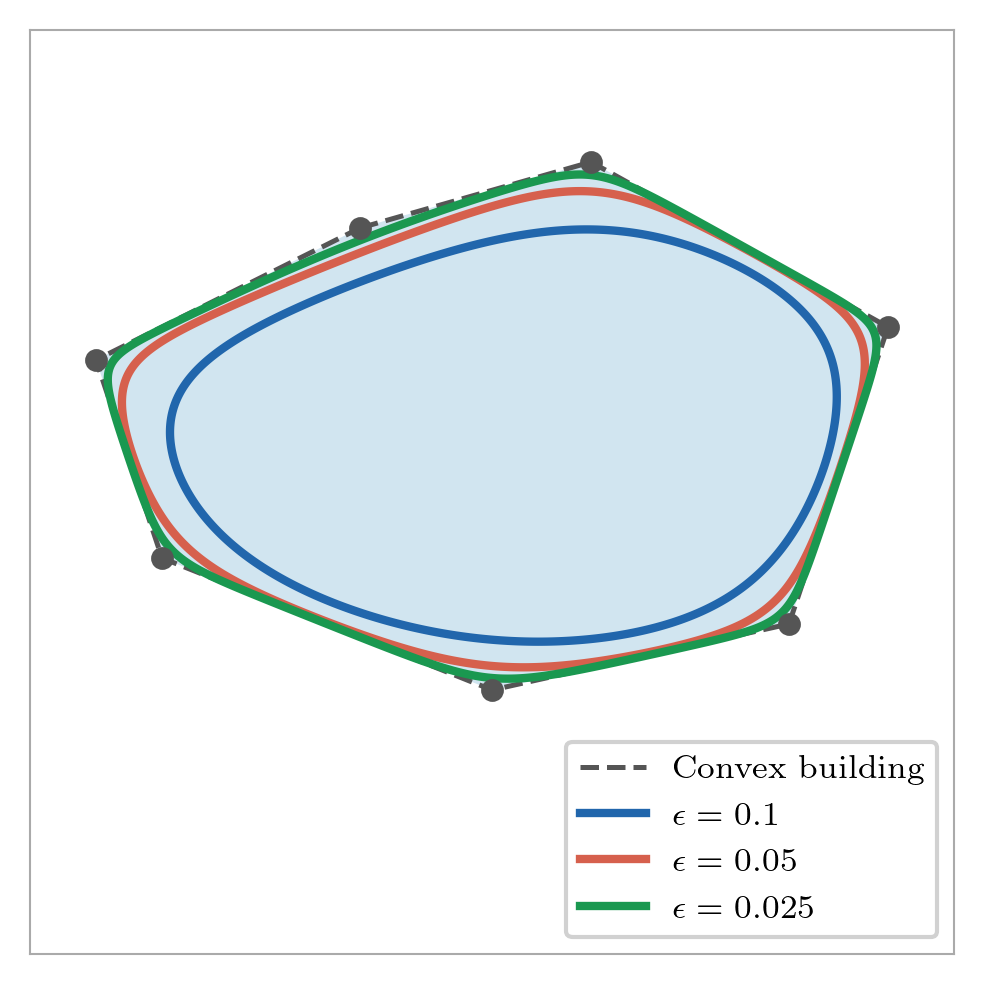

In [12]:
mpl.rcParams['font.size'] = 14
mpl.rcParams['text.usetex'] = True

epsilons = [0.1, 0.05, 0.025]
colors   = ['#2166ac', '#d6604d', '#1a9850']  # blue, red, green

fig, ax = plt.subplots(figsize=(10, 3.5), dpi=300)

xx, yy = np.meshgrid(np.linspace(-0.2, 1.2, 800),
                     np.linspace(-0.4, 1.0, 800))

# Building fill
poly_patch = Polygon(vertices, closed=True,
                     facecolor='#d1e5f0', edgecolor='none', zorder=1)
ax.add_patch(poly_patch)

# Hard boundary (exact polygon)
ax.plot(verts_closed[:, 0], verts_closed[:, 1],
        color='#555555', linewidth=1.2, linestyle='--', zorder=3)

# Vertex dots on hard boundary
for v in vertices:
    ax.scatter(*v, s=20, color='#555555', zorder=5, clip_on=False)

# Plot all three smooth boundaries
for eps, color in zip(epsilons, colors):
    R = np.vectorize(lambda x, y: lse_boundary(x, y, A_mat, b_vec, eps))(xx, yy)
    ax.contour(xx, yy, R, levels=[0.0],
               colors=[color], linewidths=2.0, zorder=4)

# ax.set_xlim(-0.2, 1.2)
# ax.set_ylim(-0.2, 1.2)
ax.set_xlim(-0.2, 1.2)
ax.set_ylim(-0.4, 1.0)
ax.set_aspect('equal')
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_color('#aaaaaa')

# Legend
hard_line = Line2D([0], [0], color='#555555', linewidth=1.2,
                   linestyle='--', label=r'Convex building')
legend_handles = [hard_line] + [
    Line2D([0], [0], color=color, linewidth=2.0,
           label=r'$\epsilon = ' + str(eps) + r'$')
    for eps, color in zip(epsilons, colors)
]
ax.legend(handles=legend_handles,
          fontsize=8, loc='lower right',
          framealpha=0.9, edgecolor='#cccccc')

plt.tight_layout()
plt.savefig("concept_diagram_sec_III_A_epsilon_single_plot.pdf", bbox_inches="tight", dpi=300)